### Exploring Buzsaki Ultra-Flexible Tentacle Electrode Data - RAT

This notebook serves to explore different preprocessing and postprocessing steps with spikeInterface using UFTE LFP data. 

ETH_F_R01_20260311\homecage_260311_144123

***

Load data into the proper format for SpikeInterface

Create a probe for the data and match the two 

Show general stats / visualize the data quickly 

identify any regions that are extremely noisy (example beginning of buszaki data) maybe make a function that will identify these regions and gives the start and end time of these (or index) 

other than those already marked as problematic from the XML file, identify which other channels are noise (ie, waves or other type of noise (figure out what types of noise there are))

Preprocess (give possibility to explore different functions and to give stats on which is best / add any functions that could be useful given our particular data (ie not knowing the x-coord with certainty))

spike sorting, have access to different algorithms and give benchmarking results on which are good and which are less good / why 
- determine a metric 

convert data into NWB format / output to phy ? 

***
### Loading data

In [1]:
import spikeinterface as si 
import spikeinterface.preprocessing as spre
from dataLoading_utils import getXMLData
from dataAnalysis_utils import find_repetitive_channels
import numpy as np
import spikeinterface.widgets as sw
import matplotlib.pyplot as plt
from probeinterface import Probe, ProbeGroup, generate_linear_probe, generate_multi_shank, combine_probes 
from probeinterface.plotting import plot_probe

In [2]:
dat_path = r"D:\Yanik Lab Dropbox\Peter Gombkoto\Multiarea rat recordings\Buzsaki\RAT\ETH_F_R01_20260311\homecage_260311_144123\amplifier.dat" #r"/Volumes/Trenholm2/neuroTechData/amplifier.dat" 
xml_path = r"D:\Yanik Lab Dropbox\Peter Gombkoto\Multiarea rat recordings\Buzsaki\RAT\ETH_F_R01_20260311\homecage_260311_144123\amplifier.xml" #r"/Volumes/Trenholm2/neuroTechData/amplifier.xml",

channel_ids, skippedChannels, xml_data = getXMLData(xml_path)
nBits, nChannels, samplingRate, offset, lfpSamplingRate = xml_data
uV_per_count = 0.195 #https://intantech.com/files/Intan_RHX_user_guide.pdf

print(f"Channels to skip based on xml: {skippedChannels}")

Channels to skip based on xml: [49, 15, 113, 120, 87]


### Create a Recording object

Select only channels from shank 2 ([64:])

In [3]:
recording = si.read_binary(file_paths=dat_path, sampling_frequency=samplingRate, dtype=f"int{nBits}", num_channels=nChannels, channel_ids=channel_ids, is_filtered=False, gain_to_uV=uV_per_count, offset_to_uV=0.0)
shank2_channel_ids = np.array(channel_ids[64:])
print(f"Shank 2 channel IDs: {shank2_channel_ids}")


shank2_recording = recording.select_channels(channel_ids=shank2_channel_ids)
shank2_recording

Shank 2 channel IDs: [112 110 113 111 114 108 115 109 116 106 117 107 118 104 119 105 120 102
  79  81  78  80  77  83  76  82  75  85  73  84 121 103 122 100  74  87
  72  86  71  89  70  88  69  91  68  90  67  93  66  92  65  95  64  94
 127  97 126  96 125  99 124  98 123 101]


ChannelSliceRecording: 64 channels - 20.0kHz - 1 segments - 56,150,640 samples 
                       2,807.53s (46.79 minutes) - int16 dtype - 6.69 GiB

Channel IDs for 10 channels of shank 2: [112 110 113 111 114 108 115 109 116 106]


C:\Users\social\AppData\Local\Temp\ipykernel_16428\4158874037.py:1: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  shank2_traces = shank2_recording.get_traces(channel_ids=shank2_channel_ids[:10], start_frame=10500000, end_frame=10510000, return_scaled=True)


[]

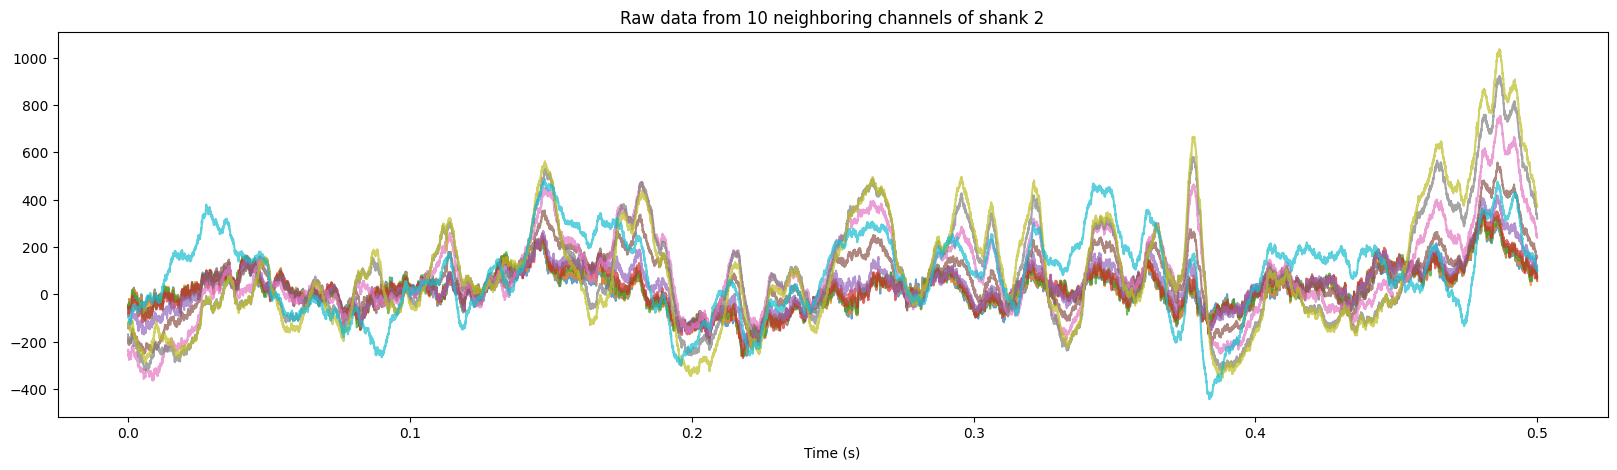

In [8]:
shank2_traces = shank2_recording.get_traces(channel_ids=shank2_channel_ids[:10], start_frame=10500000, end_frame=10510000, return_scaled=True)  
print(f"Channel IDs for 10 channels of shank 2: {shank2_channel_ids[:10]}")

t = np.arange(shank2_traces.shape[0]) / (samplingRate) # Time vector in seconds

# plot sample channels to get an idea of what the data looks like 

plt.figure(figsize=(20, 5))
plt.plot(t, shank2_traces, alpha=0.7)  
plt.title("Raw data from 10 neighboring channels of shank 2")
plt.xlabel("Time (s)")
plt.plot()

### Create a Probe

First create a flat probe given the known geometry and model the wire bending to get the final x and y coordinates for each contact site. 

'# remove channels already identified as bad in the xml file\nshank2_skipped_channels = np.intersect1d(shank2_channel_ids, skippedChannels)\nprint(f"Shank 2 channels to skip: {shank2_skipped_channels}")  \nclean_recording = shank2_recording.remove_channels(shank2_skipped_channels)\nclean_channel_ids = clean_recording.get_channel_ids()\nsw.plot_probe_map(clean_recording)'

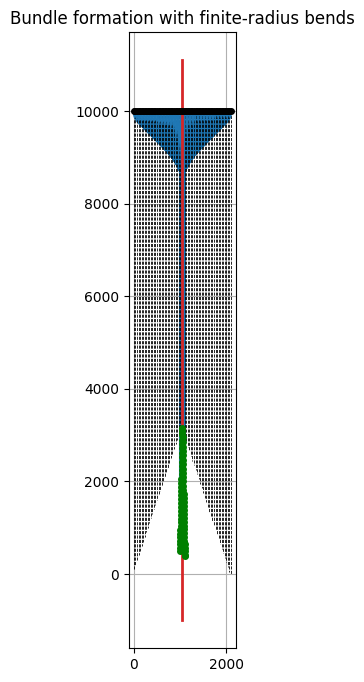

In [15]:
from probeGeom import create_flat_geom
from clean_bending_model import BundleParameters, run_from_array

# set parameters for probe geometry 
num_contact_sites = 64
y_flat_contact_dist = 50 # um 
x_flat_contact_dist = 33.3 # um (based on figure from https://www.nature.com/articles/s41467-024-49226-9#Sec7)
final_probe_width = 80 # um
base_length = 10000.0  # choose something comfortably larger than the max y offset

electrode_tips = create_flat_geom(num_contact_sites, x_flat_contact_dist, y_flat_contact_dist)
electrode_base = np.column_stack((electrode_tips[:,0], np.ones(num_contact_sites)*base_length))

params = BundleParameters(
    first_bend_distance=150.0,
    max_bend_angle_deg=45.0,
    bundle_ratio=0.05,
    first_radius=300.0,
    second_radius=300.0,
)

result = run_from_array(electrode_base, electrode_tips,params=params, make_plot=True)

# create the SpikeInterface probe object and plot it
probe = Probe(ndim=2, si_units='um')
probe.set_contacts(positions=result.ends, shapes=np.array(['square'] * num_contact_sites), shape_params={"width": 13})
#TODO
probe.set_device_channel_indices(np.arange(num_contact_sites))
probe.create_auto_shape()
    
# link the probe geometry to our recording object 
shank2 = shank2_recording.set_probe(probe, in_place=False)

'''# remove channels already identified as bad in the xml file
shank2_skipped_channels = np.intersect1d(shank2_channel_ids, skippedChannels)
print(f"Shank 2 channels to skip: {shank2_skipped_channels}")  
clean_recording = shank2_recording.remove_channels(shank2_skipped_channels)
clean_channel_ids = clean_recording.get_channel_ids()
sw.plot_probe_map(clean_recording)'''

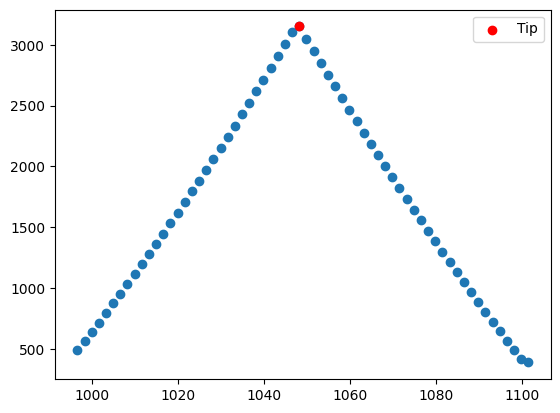

In [ ]:
result.ends
plt.scatter(result.ends[:,0], result.ends[:,1], label=)
plt.scatter(result.ends[-1,0], result.ends[-1,1], color='red', label='Tip')
plt.legend()
plt.show()

Shank2 channel IDs last 30: [ 74  87  72  86  71  89  70  88  69  91  68  90  67  93  66  92  65  95
  64  94 127  97 126  96 125  99 124  98 123 101]


[]

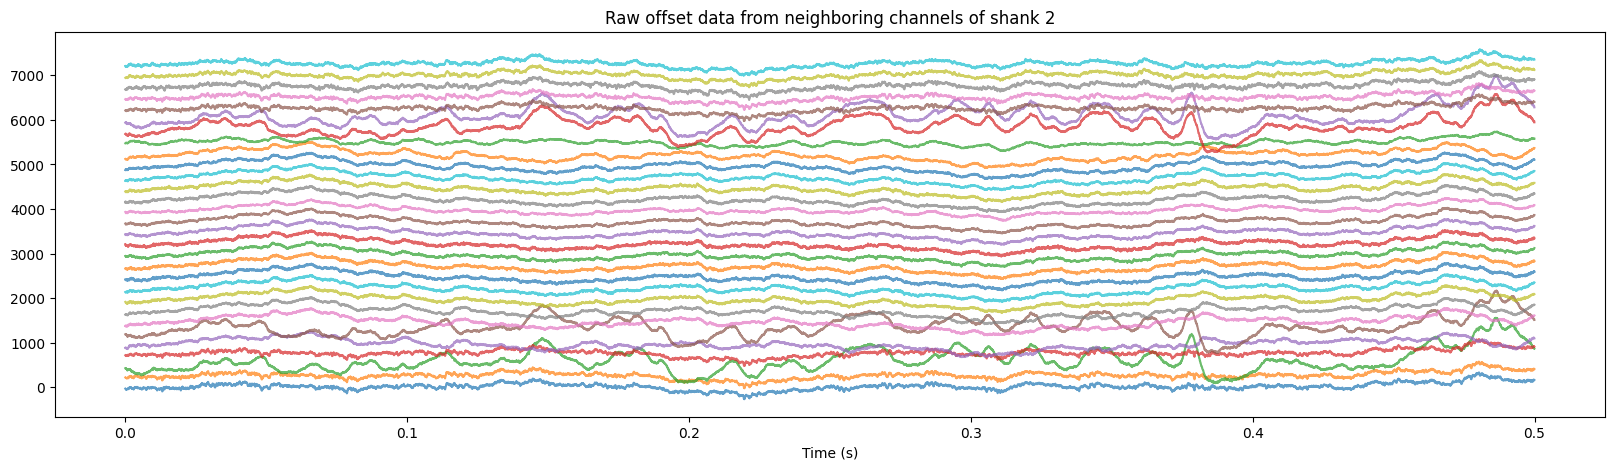

In [13]:
print(f"Shank2 channel IDs last 30: {shank2_channel_ids[-30:]}")
clean_traces = shank2_recording.get_traces(channel_ids=shank2_channel_ids[-30:], start_frame=10500000, end_frame=10510000, return_in_uV=True)  

t = np.arange(clean_traces.shape[0]) / (samplingRate) # Time vector in seconds
offsets = np.arange(clean_traces.shape[1]) * 250

# plot sample channels to get an idea of what the data looks like 
plt.figure(figsize=(20, 5))
plt.plot(t, clean_traces + offsets, alpha=0.7)  
plt.title("Raw offset data from neighboring channels of shank 2")
plt.xlabel("Time (s)")
plt.plot()


In [ ]:
g1 = clean_traces[:, np.array([0,1,3,25,26,27,28,29])] 
g2 = clean_traces[:, np.array([2,5,23,24])]
g3 = clean_traces[:, np.array([4,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21])]
g4 = clean_traces[:, np.array([22])]

# plot the three groups separately to see if they look different
plt.figure(figsize=(20, 5))
plt.plot(t, g1 + 500, alpha=0.7, color='red')
plt.plot(t, g2 + 1500, alpha=0.7, color='blue')
plt.plot(t, g3 + 1000, alpha=0.7, color='green')
plt.plot(t, g4, alpha=0.7, color='orange')
plt.title("Raw offset data from neighboring channels of shank 2 (grouped)")
plt.xlabel("Time (s)")
plt.ylabel("Offset")
plt.show()

trace_ids = clean_channel_ids[-30:]
print(f"blue: {trace_ids[[2,5,23,24]]}")
print(f"green: {trace_ids[[4,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21]]}")
print(f"red: {trace_ids[[0,1,3,25,26,27,28,29]]}")
print(f"orange: {trace_ids[[22]]}")

In [ ]:
# detect bad channels 

bad_channel_ids, channel_labels = spre.detect_bad_channels(clean_recording, method="coherence+psd")

print(f"Bad channel IDs: {bad_channel_ids}")
print(f"Bad channel labels: {channel_labels}")
print(len(channel_labels))

***

In [ ]:
# OPTIONAL: See data loading
# - modifying the xml 'skip' parameter based on impedance excel 

Current questions: 
- distances between contact sites for our flexible electrodes are not constant
- probes are not inserted vertically so they have a z component as well, does this make a difference
- the xc are all identical as we assume contact sites to be about stacked on the vertical axis. is this a valid assumption 

Before we explore any data, we can first determine which channels are dead or not valid. 

In [ ]:
# full recording
rec = recording

# attach the probe first
rec = rec.set_probe(probe, in_place=False)

bad_channel_ids = [5, 9, 17]

# analysis-only view
good_channel_ids = [ch for ch in rec.channel_ids if ch not in bad_channel_ids]
rec_analysis = rec.channel_slice(good_channel_ids)

In [ ]:
spre.detect_bad_channels(recording, 
                         method='coherence+psd', 
                         std_mad_threshold=5, 
                         psd_hf_threshold=0.02,
                         dead_channel_threshold=-0.5, 
                         noisy_channel_threshold= 1.0, 
                         outside_channel_threshold=-0.75, 
                         outside_channels_location= 'top', # Literal['top', 'bottom', 'both']
                         n_neighbors = 11, 
                         nyquist_threshold =  0.8, 
                         direction = 'y', # Literal['x', 'y', 'z'] 
                         chunk_duration_s = 0.3, 
                         num_random_chunks = 100, 
                         welch_window_ms = 10.0, 
                         highpass_filter_cutoff = 300, 
                         neighborhood_r2_threshold = 0.9,
                         neighborhood_r2_radius_um = 30.0, 
                         seed = None, 
                         channel_filters = None)

In [ ]:
def plot_channel_sliding_stats(
    recording,
    channel_id=None,
    channel_index=None,
    segment_index=0,
    start_frame=None,
    end_frame=None,
    window_s=1.0,
    step_s=None,
    dtype="float32",
):
    """
    Plot sliding-window mean and std for one channel of a SpikeInterface recording.

    Parameters
    ----------
    recording : spikeinterface RecordingExtractor
        Your recording object.
    channel_id : optional
        Channel id to analyze.
    channel_index : optional
        Channel index to analyze. Used if channel_id is None.
    segment_index : int
        Segment to analyze.
    start_frame, end_frame : int or None
        Frame range to analyze. Defaults to full segment.
    window_s : float
        Sliding window length in seconds.
    step_s : float or None
        Step between windows in seconds. If None, uses window_s / 10.
    dtype : str
        dtype used when loading trace.

    Returns
    -------
    times : np.ndarray
        Window center times in seconds.
    means : np.ndarray
        Sliding mean.
    stds : np.ndarray
        Sliding std.
    """
    fs = recording.get_sampling_frequency()
    num_frames = recording.get_num_frames(segment_index=segment_index)

    if start_frame is None:
        start_frame = 0
    if end_frame is None:
        end_frame = num_frames

    if channel_id is None:
        if channel_index is None:
            channel_index = 0
        channel_id = recording.channel_ids[channel_index]

    if step_s is None:
        step_s = window_s / 10

    window = max(1, int(round(window_s * fs)))
    step = max(1, int(round(step_s * fs)))

    if end_frame <= start_frame:
        raise ValueError("end_frame must be greater than start_frame")
    if window > (end_frame - start_frame):
        raise ValueError("window is larger than selected data interval")

    # Load one channel only -> fast and memory-efficient
    x = recording.get_traces(
        segment_index=segment_index,
        start_frame=start_frame,
        end_frame=end_frame,
        channel_ids=[channel_id],
        return_in_uV=False,
    ).astype(dtype, copy=False).squeeze()

    # Cumulative sums for O(N) sliding mean/std
    x64 = x.astype(np.float64, copy=False)
    csum = np.concatenate(([0.0], np.cumsum(x64)))
    csum2 = np.concatenate(([0.0], np.cumsum(x64 * x64)))

    starts = np.arange(0, len(x) - window + 1, step)
    ends = starts + window

    sums = csum[ends] - csum[starts]
    sums2 = csum2[ends] - csum2[starts]

    means = sums / window
    vars_ = sums2 / window - means**2
    vars_ = np.maximum(vars_, 0.0)  # numerical safety
    stds = np.sqrt(vars_)

    centers = starts + window / 2
    times = (start_frame + centers) / fs

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    axes[0].plot(times, means)
    axes[0].set_ylabel("Mean")
    axes[0].set_title(
        f"Sliding statistics | channel={channel_id} | "
        f"window={window_s:.3f}s | step={step_s:.3f}s"
    )
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(times, stds)
    axes[1].set_ylabel("Std")
    axes[1].set_xlabel("Time (s)")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return times, means, stds

times, means, stds = plot_channel_sliding_stats(recording, channel_id=channel_ids[45], window_s=2.0, step_s=0.2)

### Create a probe object

For now, we assume the probe to be fixed and linear

- `set_contact_ids`: metadata 
- `set_device_channel_indices`: hardware mapping

In [ ]:
# generate multiple individual linear shanks and combine them into a multi-shank probe
shank1 = generate_linear_probe(num_elec = 64, ypitch = 15.5, contact_shapes="square", contact_shape_params={"width": 13})
shank1.set_device_channel_indices(channel_ids[:64]) # set the channel ids for the first shank
shank2 = generate_linear_probe(num_elec = 64, ypitch = 50.0, contact_shapes="square", contact_shape_params={"width": 13})
shank2.set_device_channel_indices(channel_ids[64:]) # set the channel ids for the second shank

# define the x-axis position of the shanks
shank2.move([3000, 0])

multiShank_probe = combine_probes([shank1, shank2])

recording.set_probe(multiShank_probe)

In [ ]:
plot_probe(multiShank_probe)

***

### Preprocessing

Beware of which steps do and do not use the probe geometry. 

Geometry agnostic: bandpass_filter, highpass_filter, notch_filter, generic filter, center, zscore, scale, clip, astype, resample, rectify, phase_shift, whiten

Geometry-dependent: CAR, average_across_direction, directional_derivative, highpass_spatial_filter, depth_order, compute_motion, correction_motion

Kilosort4 performs the following preprocessing steps:
1. remove mean across channels 
2. CAR
3. temporal filtering per-channel filtering high pass filter at 300Hz 
4. local channel whitening (uses local 32 channels) 
5. drift estimation and correction 

In [ ]:
o = spre.center(recording, mode='median', dtype='float32')

In [ ]:
si.preprocessing.whiten(recording, dtype=None, apply_mean=False, regularize=False, regularize_kwargs=None, mode='global', radius_um=100.0, int_scale=None, eps=None, W=None, M=None, **random_chunk_kwargs)
si.preprocessing.bandpass_filter(recording, freq_min=300.0, freq_max=6000.0, margin_ms='auto', dtype=None, ignore_low_freq_error=False, _skip_margin_warning_for_old_version=False, **filter_kwargs)


In [ ]:

spikeinterface.preprocessing.common_reference(recording: BaseRecording, reference: Literal['global', 'single', 'local'] = 'global', operator: Literal['median', 'average'] = 'median', groups: list | None = None, ref_channel_ids: list | str | int | None = None, local_radius: tuple[float, float] = (30.0, 55.0), min_local_neighbors: int = 5, dtype: str | dtype | None = None)
spikeinterface.preprocessing.compute_motion(recording: BaseRecording, preset: Literal['dredge', 'medicine', 'dredge_fast', 'nonrigid_accurate', 'nonrigid_fast_and_accurate', 'rigid_fast', 'kilosort_like'] = 'dredge_fast', detect_kwargs: dict = {}, select_kwargs: dict = {}, localize_peaks_kwargs: dict = {}, estimate_motion_kwargs: dict = {}, output_motion_info: bool = False, folder: str | Path | None = None, overwrite: bool = False, raise_error: bool = True, **job_kwargs)→ dict

spikeinterface.preprocessing.average_across_direction(parent_recording: BaseRecording, direction: str = 'y', dtype='float32')
spikeinterface.preprocessing.correct_motion(recording: BaseRecording, preset: Literal['dredge', 'medicine', 'dredge_fast', 'nonrigid_accurate', 'nonrigid_fast_and_accurate', 'rigid_fast', 'kilosort_like'] = 'dredge_fast', folder: str | Path | None = None, output_motion: bool = False, output_motion_info: bool = False, overwrite: bool = False, detect_kwargs: dict = {}, select_kwargs: dict = {}, localize_peaks_kwargs: dict = {}, estimate_motion_kwargs: dict = {}, interpolate_motion_kwargs: dict = {}, **job_kwargs)
spikeinterface.preprocessing.detect_bad_channels(recording: BaseRecording, method: str = 'coherence+psd', std_mad_threshold: float = 5, psd_hf_threshold: float = 0.02, dead_channel_threshold: float = -0.5, noisy_channel_threshold: float = 1.0, outside_channel_threshold: float = -0.75, outside_channels_location: Literal['top', 'bottom', 'both'] = 'top', n_neighbors: int = 11, nyquist_threshold: float = 0.8, direction: Literal['x', 'y', 'z'] = 'y', chunk_duration_s: float = 0.3, num_random_chunks: int = 100, welch_window_ms: float = 10.0, highpass_filter_cutoff: float = 300, neighborhood_r2_threshold: float = 0.9, neighborhood_r2_radius_um: float = 30.0, seed: int | None = None, channel_filters: set | None = None)
spikeinterface.preprocessing.detect_artifact_periods(recording: BaseRecording, method: Literal['envelope', 'saturation'] = 'envelope', method_kwargs: dict | None = None, job_kwargs: dict | None = None)→ ndarray
spikeinterface.preprocessing.filter(recording, band=(300.0, 6000.0), btype='bandpass', filter_order=5, ftype='butter', filter_mode='sos', margin_ms=None, add_reflect_padding=False, coeff=None, dtype=None, direction='forward-backward')


***

In [ ]:
w_ts = sw.plot_traces(recording, channel_ids=channel_ids[:10])

**consider using the read_binary_folder function to concatinate multiple sessions together